In [ ]:
Content
1. OOPs
2. FAQs
3. Code examples for Relation

# 1. OOPs

In [ ]:
It programming paradigm based on the concept of “objects”, which bundle data (attributes) and behavior (methods) into single units.
It is mainly about organizing your code like real-world objects (e.g., a Car object with properties like color, model, and behaviors like drive() or brake()

Benefits:
    1. Modularity: Code is modular and reusable via classes.
    2. Scalability: Easier to maintain and scale.    3. Reusablity: Supports Inheritance and composition
    4. Data Stafety: Data is protected through encapsulation.
    5. Real world data modeling
    

In [ ]:
# General OOP related concepts - Relation b/w entities:

                                OOPs
                                 |
         -------------------------------------------------
         |                                               |
     Inheritance                                    Association
         |                                               |
 [ChildClass] ─────|> [ParentClass]           Student -------- College
                                                <<association>> (solid line)
                                                
                                                   |
                                    ---------------------------------
                                    |                               |
                             Composition                      Aggregation
                    Human  ◆──────────────  heart               Team  ◇──────────────  Player
                          <<composition>>                              <<aggregation>>
                           
Example: Company Owns a Team that has Players
               Company ◆───────────     Team  ◇───── Players


1. Inheritance: (is-a) relationship, It allows child sub-class to inherit properties and behaviours from a parent class.
    - Tightly coupled, Inherits everthing, mainly used for Natural/ real-world heiharchies
    - Ex: A car is a vehicle.
    - Key points:
         1. In C/ java: the parent constructor is always automatically called when a child object.
         2. In python, you may skip calling the parent constructor.  
         3. Rules in python constructor calling
            •	If a child class does not define its own __init__(), then Python will use the __init__() from its nearest base class (per MRO — method resolution order).
            •	But if the child defines its own __init__(), Python will not automatically call the parent’s unless you write super().__init__().
                                                      
                                                      
                                                        
class Vehicle:
    def __init__(self, brand):
        self.brand = brand

    def start(self):
        print(f"{self.brand} vehicle is starting...")

class Car(Vehicle):
    def open_trunk(self):
        print("Trunk is open.")

my_car = Car("Toyota")
my_car.start()         # Inherited from Vehicle
my_car.open_trunk()    # Car-specific method

# UML
- Car inherits from vehicle
Car  ─────|>  Vehicle
<<inheritance>> (solid line, hollow arraw)

2. Association
  - it represents a relationship between two separate classes which are connected logically but have independent lifecycles
  - Ex: A student can exist without a collage (and vice-versa).
  - It has two types: Composition and Aggregation.
class Student:
    def __init__(self, name):
        self.name = name

class College:
    def __init__(self, college_name):
        self.college_name = college_name

# Association: Student linked to College
s1 = Student("Sourav")
c1 = College("Delhi")

# UML
- Both can exist independently
Student  ──────────────  College
         <<association>> (solid line)

2.1. Composition: Strong (Has-a) relationship, Composition means a class is composed of one or more other classes (objects) as members.
    - Loosely coupled, Can choose a part to re-use, more flexible.
    - Ex: A Car has a GPS, Engine.
    - Strong Has-a relationship
    - Child object dies with the parent. If parent object is destroyed, the child object destroyed too.
    - Full ownership
    - Ex: Human has a heart (dies with human)
    - In following ex: Car creates and manages the object of Engine.
    - Example: https://github.com/SouravAggarwal/design-patterns/blob/main/design-patterns/src/main/java/org/prateek/Basics/UML/CompositionExample.java

class Engine:
    def start(self):
        print("Engine started")

class Car:
    def __init__(self, brand):
        self.brand = brand
        self.engine = Engine()  # Car has an Engine

    def start(self):
        print(f"{self.brand} car is starting...")
        self.engine.start()

my_car = Car("Honda")
my_car.start()

# UML
- House has Rooms (destroying House destroys Rooms)
House  ◆──────────────  Room
       <<composition>>

    
2.2. Aggregation: Weak (Has-a) relationship.
   - One object uses another — but does not own it.
   - Weak/ Loose relationship, the child may exist without the parent.
   - Ex: Team has a player. Team would still exist even if a player goes out.
   - Ex: Student instantiated and lives independently. Even if school is deleted.

class Student:
    def __init__(self, name):
        self.name = name

class School:
    def __init__(self):
        self.students = []  # Aggregation

    def add_student(self, student):
        self.students.append(student)

s1 = Student("Alice")
s2 = Student("Bob")

school = School()
school.add_student(s1)
school.add_student(s2)

# UML Diagram
- Team has Players (Players can exist independently)
Team  ◇──────────────  Player
      <<aggregation>>



3. Dependency
  - A dependency is a “uses” relationship between two classes — one class depends on another because it uses it temporarily, often as a method parameter, local variable, or return type.
  - Example: Doctor depends on Prescription to perform an action, but does not own or store it as an attribute.
      
class Prescription:
    def __init__(self, medicine):
        self.medicine = medicine

class Doctor:
    def write_prescription(self, patient_name, prescription: Prescription):
        print(f"Dr. is writing prescription for {patient_name}: {prescription.medicine}")

# UML
+---------+             +---------------+
|  Doctor | --------->  | Prescription  |
+---------+   <<uses>>  +---------------+
     <<dependency>> (doted line with arrow) 

4. Realization (for Interfaces): 
  - Used when a class implements an interface or an abstract class implements another interface.
      
from abc import ABC, abstractmethod

class Printable(ABC):
    @abstractmethod
    def print(self):
        pass

class Document(Printable):
    def print(self):
        print("Printing document...")

# UML
 Document -------|> IPrintable
(doted line with hollow triangle) 

5. Generalization: Generalization is the process of extracting shared characteristics (fields, behaviors) from two or more classes and combining them into a generalized superclass.
    - Example Dog and Cat class are inherited from Animal class
    - Parent class has all the common properties.

6. Specification: Creating child/ concrete classes from parent.
    - It is opposite of Generalization.

In [ ]:
# Generatl OOP related concepts:

3. Class: Blueprint of an object.
4. Object: Instance of an class.
5. Abstract Class: Class can not be instantiated, may contain both implemented and abstract method.
   - It serves as a base or template class for others.
   - Abstract class can have it is own implementation, It can have fields, supports only one class Inheritance.
   - Purpose: partial implemented methods and other abstract.
   - It has a constructor, but You can’t call it directly, but it will be called automatically when a subclass is instantiated.

6. Interface: An interface is a contract that specifies what methods a class must implement — but does not provide any implementation.
   - Can not have implementation, No class fields, supports multiple inheritance.
   - Purpose: Only Contract.

6.1 Interface Segregation Principle
  - Clients should not be forced to implement the methods they do not want to use.
        public interface IPrinter {
            void Print();
        }
        
        public interface IScanner {
            void Scan();
        }
        
        public class SimplePrinter : IPrinter {
            public void Print() { /* OK */ }
        }

7. High Cohesion: A highly cohesive class does one thing really well.
   - Cohesion: Cohesion means how focused and related the responsibilities of a class or module are.
   - It follows the Single Responsibility principle
   - One class just does one thing/ has one responsibility.




In [ ]:
8. Coupling:
   - Coupling is the degree to which one class or module depends on another.
   - Low Coupling: More flexibility, less dependency, easy to replace components.
	•	Loose (low) coupling = minimal dependency
	•	Tight (high) coupling = high interdependency

# Example of Tight coupling
class EmailService {
    public void SendEmail(string message) {
        Console.WriteLine("Sending email: " + message);
    }
}

class NotificationManager {
    private EmailService emailService = new EmailService(); // tightly coupled

    public void NotifyUser() {
        emailService.SendEmail("You have a notification!");
    }
}


# Example of loose coupling

interface INotificationService {
    void Send(string message);
}

class EmailService : INotificationService {
    public void Send(string message) {
        Console.WriteLine("Email: " + message);
    }
}

class SMSService : INotificationService {
    public void Send(string message) {
        Console.WriteLine("SMS: " + message);
    }
}

class NotificationManager {
    private readonly INotificationService notificationService;

    public NotificationManager(INotificationService service) {
        this.notificationService = service;
    }

    public void NotifyUser() {
        notificationService.Send("You have a notification!");
    }
}

In [ ]:
# Pillars of OOP
1. Encapsulation: Wrapping data and methods into a single unit (class). Hiding internal state and requiring all interaction to be performed through methods
   - It is achieved by usiing getter/ setters. and public/private access modifiers.

2. Abstraction: Hiding complex implementation and exposing essential features.
  - Achieved using abstract classes or interfaces.

        from abc import ABC, abstractmethod
        
        class Vehicle(ABC):
            @abstractmethod
            def move(self):
                pass
        
        class Car(Vehicle):
            def move(self):
                print("Car is moving")
        
        v = Car()
        v.move()

3. Inheritance: Child class acquires the properties of parent class.
4. Polymorphism: means many forms, the same method to behave differently based on the context
  A. Compile time: method overloading, the same class having multiple methods with same name but with different arguments.
  B. Runtime Polymorphism: Same method name, but different class. Child class overriding the parent method.
        class Animal:
            def speak(self):
                return "Some sound"
        
        class Dog(Animal):
            def speak(self):
                return "Woof"
        
        class Cat(Animal):
            def speak(self):
                return "Meow"
            
    def animal_speak(animal: Animal):
        print(animal.speak())
    
    dog = Dog()
    cat = Cat()
    
    animal_speak(dog)  # Woof
    animal_speak(cat)  # Meow

In [ ]:
# Resources
- For UML Diagram:  https://sparxsystems.com/resources/tutorials/uml2/class-diagram.html
- For Class Code Relation (In java): https://github.com/SouravAggarwal/design-patterns/blob/main/design-patterns/src/main/java/org/prateek/Basics/UML/AggregationExample.java

### Comparision
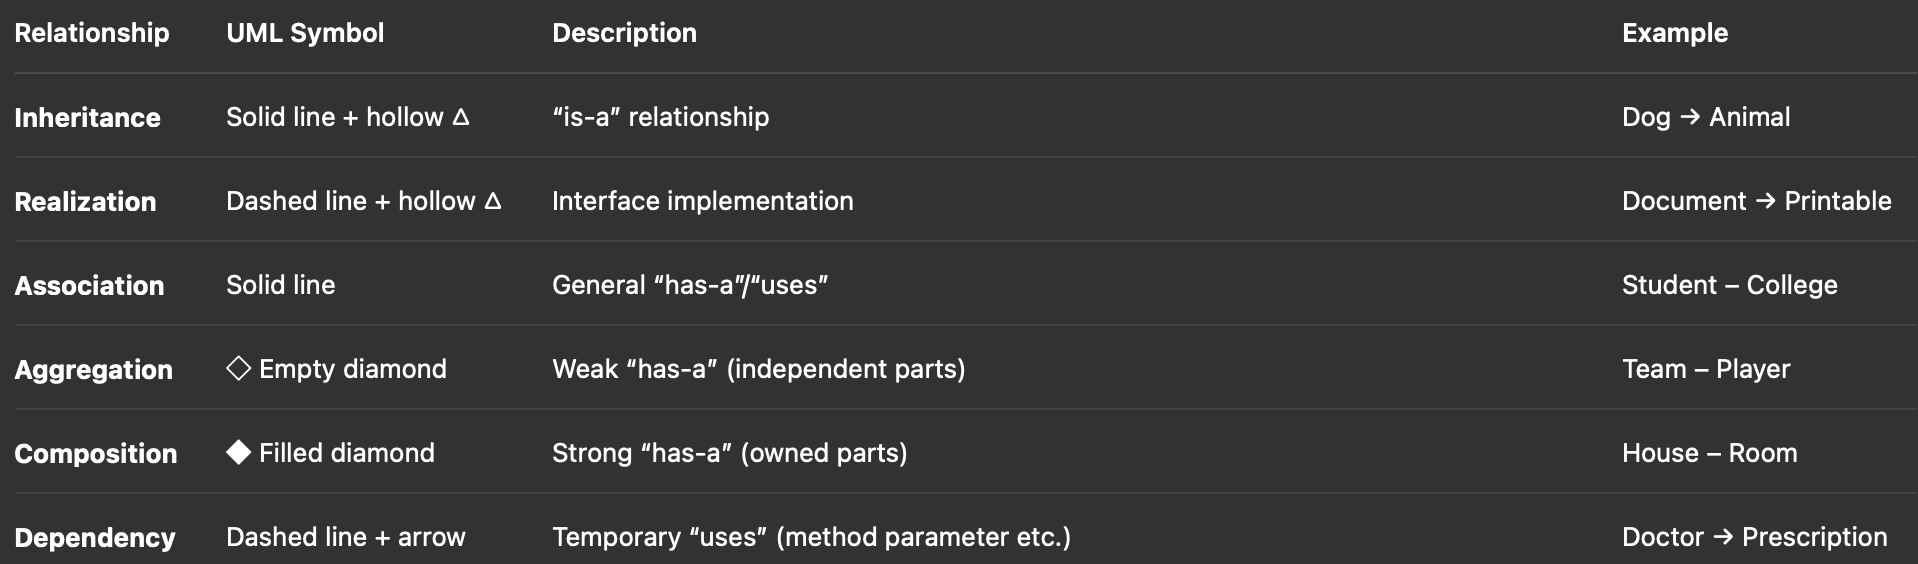

# 2. FAQs

In [ ]:
1. How do you ensure your code is cohesive and loosely coupled?
 - We follow SOLID principles, especially SRP for cohesion and Dependency Inversion/Injection for loose coupling. We try to keep classes focused on a single responsibility and depend on abstractions rather than concrete implementations

2. Encapsulation focuses on hiding the data/ restricting access to data members/ methods, while abstraction focus on hiding implementation details.
     

In [9]:
class Parent:
    def __init__(self, x):
        print("Parent constructor" + x)

class Child(Parent):
    def __init__(self):
        print("Child constructor")

c = Child()

Child constructor


# 3. Code Examples for Relation

In [26]:
# Python specific only

# 1. Inheritance: Parent constructor is auto-called.
class Vehicle:
    def __init__(self, brand):
        self.brand1 = brand

    def start(self):
        print(f"{self.brand1} vehicle is starting...")

class Car(Vehicle):
    def open_trunk(self):
        print("Trunk is open.")

my_car = Car("Toyota")
my_car.start()         # Inherited from Vehicle
my_car.open_trunk()    # Car-specific method

# 2. Correct way: calling parent constructor explicitely
class Car(Vehicle):
    def __init__(self, brand):
        super().__init__(brand)  # manually call parent constructor
        print("Car constructor")
        
# 3. Inheritance: Parent constructor is not called at all.
class Parent:
    def __init__(self, x):
        self.x = x
        
    def __init__(self):
        print("Parent constructor called")
        
    def calls(self):
        print("Parent constructor called" + self.x)


class Child(Parent):
    def __init__(self):
        print("Child constructor only — no super() call")

c =Child()
c.calls()  # throws error as self.x is undefined.

Toyota vehicle is starting...
Trunk is open.
Child constructor only — no super() call
